In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from parameterrun import parameterrun
from scipy.interpolate import CubicSpline
from tqdm.auto import tqdm

from geodesiq import Hamiltonian

In [3]:
def H_fun(eps, DeltaL, DeltaR, tc, phiL, phiR):
    tee = tc / 2 * (1 + np.exp(1j * (phiL - phiR)))
    tgg = tc / 2 * (1 + np.exp(-1j * (phiL - phiR)))

    teg = tc / 2 * (np.exp(1j * phiL) * np.exp(1j * phiR))
    tge = -tc / 2 * (np.exp(-1j * phiL) * np.exp(-1j * phiR))

    return np.array([[eps + np.abs(DeltaL), 0, tee, teg], [0, eps - np.abs(DeltaL), tge, tgg],
                     [tee.conjugate(), tge.conjugate(), -eps + np.abs(DeltaR), 0],
                     [teg.conjugate(), tgg.conjugate(), 0, -eps - np.abs(DeltaR)]])


def H_partial(eps, DeltaL, DeltaR, tc, phiL, phiR):
    return np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])


DeltaL = 1
tc = 0.5 * DeltaL
DeltaR = 5 * DeltaL
phiL = 0.1
phiR = np.pi / 2
eps_min = -10 * DeltaL
eps_max = 10 * DeltaL

In [4]:
eps_s = np.linspace(eps_min, eps_max, 1001)

hypermatrix = np.array([H_fun(eps_i, DeltaL, DeltaR, tc, phiL, phiR) for eps_i in eps_s])
energies = np.linalg.eigvalsh(hypermatrix)

(-5.0, 5.0)

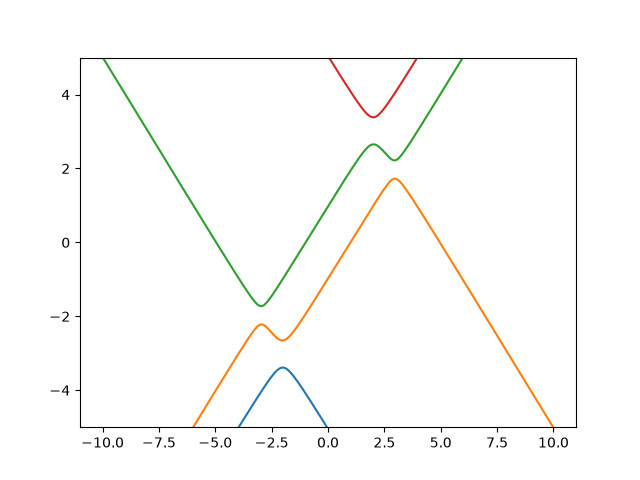

In [5]:
fig, ax = plt.subplots()
ax.plot(eps_s, energies)
ax.set_ylim(-5, 5)

In [6]:
alpha = 4
beta = 2
dia_alpha = -2.5
dia_beta = 3

initial_state = 0
final_state = 1

hamiltonian = Hamiltonian(H_fun, partial_H_func=H_partial)
hamiltonian.set_parameters(DeltaL=DeltaL, DeltaR=DeltaR, phiL=phiL, phiR=phiR, tc=tc)
hamiltonian.set_control(control_name='eps', pulse_initial=eps_min, pulse_final=eps_max, initial_state=initial_state,
                        final_state=final_state, alpha=alpha, beta=beta, dia_alpha=dia_alpha, dia_beta=dia_beta)

hamiltonian.solve_problem(pulse_accuracy=int(1e6))
pulse = hamiltonian.synthesize_pulse(1)

psi_0 = qt.Qobj(H_fun(eps_min, DeltaL, DeltaR, tc, phiL, phiR)).eigenstates()[1][initial_state]
psi_target = qt.Qobj(H_fun(eps_max, DeltaL, DeltaR, tc, phiL, phiR)).eigenstates()[1][final_state]

In [7]:
hamiltonian._dia_list

array([[-1,  0,  1,  1],
       [ 0, -1,  1,  1],
       [ 1,  1, -1,  1],
       [ 1,  1,  1, -1]])

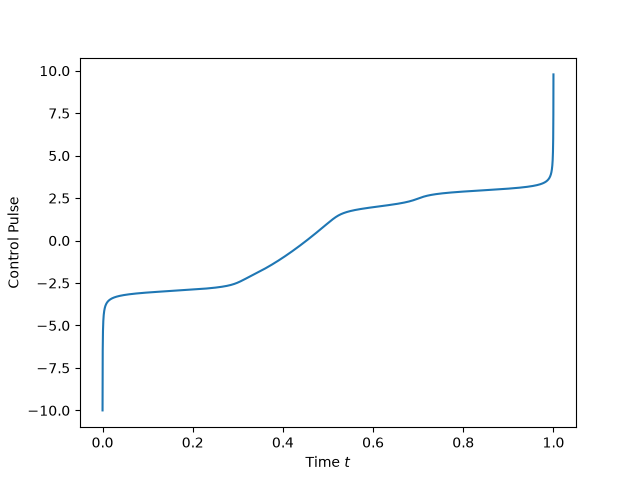

In [10]:
pulse.plot_pulse();

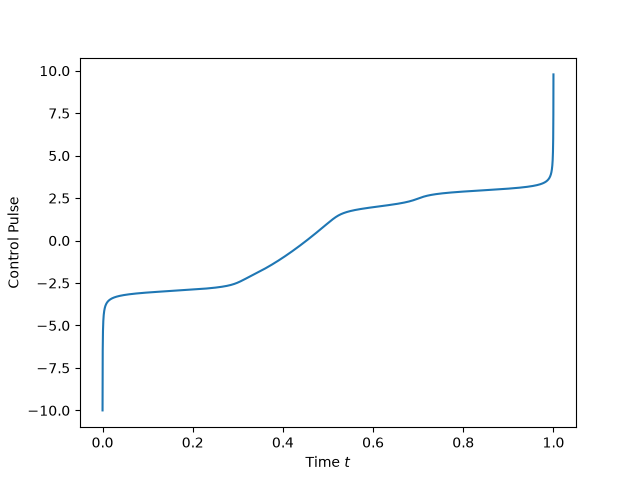

In [12]:
hamiltonian.set_control(dia_alpha=-2.5, dia_beta=3)
hamiltonian.solve_problem(pulse_accuracy=int(1e6))
pulse = hamiltonian._control_sol
pulse_2 = hamiltonian.synthesize_pulse(1)
pulse_2.plot_pulse()

tf = 10
pulse = CubicSpline(np.linspace(0, tf, len(pulse)), pulse)
time = np.linspace(0, tf, 1000)
H0 = qt.Qobj(H_fun(0, DeltaL, DeltaR, tc, phiL, phiR))
Hd = qt.Qobj(H_fun(1, 0, 0, 0, 0, 0))
Ht = qt.QobjEvo([H0, [Hd, pulse]])

In [13]:
def compute_fidelity(pulse, tf):
    pulse = CubicSpline(np.linspace(0, tf, len(pulse)), pulse)

    time = np.linspace(0, tf, 1000)

    H0 = qt.Qobj(H_fun(0, DeltaL, DeltaR, tc, phiL, phiR))
    Hd = qt.Qobj(H_fun(1, 0, 0, 0, 0, 0))
    Ht = qt.QobjEvo([H0, [Hd, pulse]])

    psi_f = qt.sesolve(Ht, psi_0, time).final_state
    fidelity = qt.fidelity(psi_target, psi_f) ** 2
    return fidelity


def compute_best_fidelity(dia_alpha, dia_beta):
    hamiltonian.set_control(dia_alpha=dia_alpha, dia_beta=dia_beta)

    hamiltonian.solve_problem(pulse_accuracy=int(1e6))
    pulse = hamiltonian._control_sol

    fidelities = parameterrun(compute_fidelity, 'tf', tfs, pulse=pulse, pbar_bool=False)
    return np.max(fidelities)


tfs = np.linspace(0.1, 500 / DeltaL, 100)

dia_alpha_s = np.linspace(-5, 5, 11)
dia_beta_s = np.linspace(-5, 5, 11)

best_fidelities = np.zeros((len(dia_alpha_s), len(dia_beta_s)))
pbar = tqdm(total=best_fidelities.size)
for i in range(len(dia_alpha_s)):
    for j in range(len(dia_beta_s)):
        best_fidelities[i, j] = compute_best_fidelity(dia_alpha_s[i], dia_beta_s[i])
        pbar.update()
pbar.close()

  0%|          | 0/121 [00:00<?, ?it/s]

/home/dfernandez/.venvs/geodesiq/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Process LokyProcess-17:
Process LokyProcess-16:
Process LokyProcess-1:
Exception ignored in garbage collection:
Traceback (most recent call last):
  File "/home/dfernandez/.venvs/geodesiq/lib/python3.13/site-packages/qutip/solver/integrator/scipy_integrator.py", line 67, in _mul_np_vec
    state = _data.dense.fast_from_numpy(vec)
SystemError: <cyfunction fast_from_numpy at 0x7e5936d94fc0> returned a result with an exception set
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/dfernandez/miniconda3/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/dfernandez

KeyboardInterrupt: 

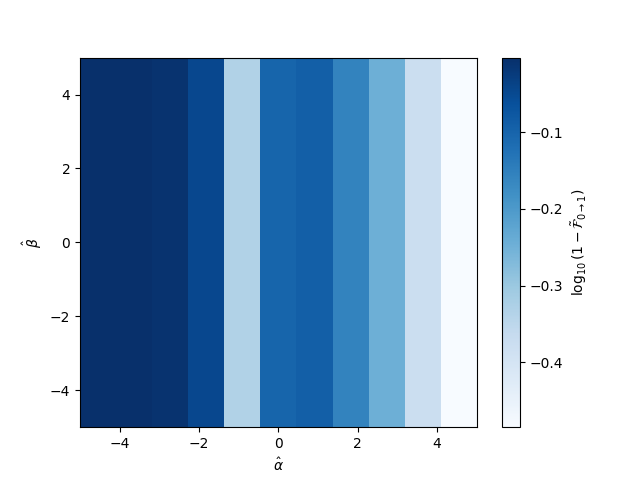

In [128]:
fig, ax = plt.subplots()

im = ax.imshow(np.log10(1 - best_fidelities).T, origin='lower', aspect='auto', cmap='Blues',
               extent=[min(dia_alpha_s), max(dia_alpha_s), min(dia_beta_s), max(dia_beta_s)])
ax.set_xlabel(r'$\hat{\alpha}$')
ax.set_ylabel(r'$\hat{\beta}$')
plt.colorbar(im, ax=ax, label=r'$\log_{10}(1 - \tilde{\mathcal{F}}_{0\rightarrow 1})$');